# NE-EpiGuard: Waterborne Disease Outbreak Prediction — Northeast India
## Exploratory Data Analysis (EDA)

---

## 1. Problem Statement

### What is a Waterborne Disease Outbreak?
Waterborne diseases are illnesses caused by pathogenic microorganisms transmitted through contaminated water. In Northeast India, a region characterized by extreme monsoon patterns, high flooding frequency, and significant variation in sanitation infrastructure across its 8 states, waterborne diseases like Cholera, Typhoid, Dysentery, Hepatitis A/E, Leptospirosis, and Giardiasis remain a persistent public health challenge.

### Why Northeast India?
The Northeast region contributes disproportionately to India's waterborne disease burden:
- **Extreme monsoon seasonality** — some districts receive 1000mm+ rainfall in June–August alone
- **High flooding incidence** — especially in Assam, Meghalaya, and Tripura floodplains
- **Sanitation gaps** — open defecation rates and untreated water sources remain elevated in remote districts
- **Geographic remoteness** — many hill districts in Arunachal Pr|adesh, Nagaland, and Mizoram have limited healthcare access, making early prediction critical

### Our Goal
Using patient-level data capturing demographics, water quality parameters, environmental conditions, sanitation indicators, and clinical symptoms across all 8 Northeast Indian states, we aim to:
1. **Understand** the distribution and drivers of each disease class
2. **Identify** which water quality parameters, climate factors, and sanitation indicators most strongly predict disease type
3. **Prepare** a clean, feature-engineered dataset for multi-class disease classification
4. **Power** an AI advisory system that provides health guidance and specialist recommendations

### Disease Classes
| Disease | Transmission Route | Key Risk Factors |
|---|---|---|
| Cholera | Fecal-oral via water | High fecal coliform, flooding, untreated water |
| Typhoid | Contaminated water/food | Poor sanitation, high TDS, open defecation |
| Dysentery | Contaminated water | High turbidity, untreated sources |
| Hepatitis A | Fecal-oral | Poor handwashing, low WQI |
| Hepatitis E | Contaminated water | Flooding, low dissolved oxygen |
| Leptospirosis | Soil/water contact | Flooding, animal contact, monsoon |
| Giardiasis | Contaminated water | Low WQI, surface water sources |
| No Disease | — | Good water quality, sanitation |

---

## 2. Basic Data Checks

In [1]:
# Basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

%matplotlib inline

# Set background graph style
plt.style.use('dark_background')

# import warnings to ignore the warnings
import warnings
warnings.filterwarnings('ignore')

# Load Dataset
data = pd.read_csv(r'D:\NE-EpiGuard\Notebooks\Data\northeast_waterborne.csv')
# 1. Check Shape
print('Data Shape:', data.shape)

# 2. View first few rows
display(data.head())

# 3. Info to see column types and non-null counts
print('\nData Info:')
data.info()

# 4. Summary statistics for numeric columns
print('\nNumeric Summary:')
display(data.describe())

# 5. Unique values per column
print('\nUnique Values Count:')
print(data.nunique())

#6 Checking duplicate rows
print('\n=== DUPLICATE ROWS ===')
print(f'Duplicates: {data.duplicated().sum()}')

Data Shape: (405074, 39)


,state,district,latitude,longitude,population_density,age,gender,water_source,water_treatment,water_quality_index,...,flooding,symptom_diarrhea,symptom_vomiting,symptom_fever,symptom_abdominal_pain,symptom_dehydration,symptom_jaundice,symptom_bloody_stool,symptom_skin_rash,disease
0,Assam,Tinsukia,25.7467,90.2411,505,22,Female,Borewell,Untreated,17.8,...,0,1,0,1,1,1,0,1,0,Dysentery
1,Assam,Darrang,27.0947,90.6179,578,50,Male,Piped,Chlorinated,99.3,...,0,0,0,0,0,0,0,0,0,No_Disease
2,Assam,Cachar,25.1711,93.2949,311,9,Male,Tanker,Untreated,28.3,...,0,0,1,1,0,0,1,0,1,Leptospirosis
3,Manipur,Ukhrul,24.2054,94.1155,179,7,Female,River,Untreated,33.5,...,0,1,1,1,1,1,1,0,0,Hepatitis_A
4,Arunachal Pradesh,Tirap,28.5052,92.9995,49,34,Male,River,Boiled,69.1,...,0,0,0,0,0,0,0,0,0,No_Disease



Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 405074 entries, 0 to 405073
Data columns (total 39 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   state                     405074 non-null  object 
 1   district                  405074 non-null  object 
 2   latitude                  405074 non-null  float64
 3   longitude                 405074 non-null  float64
 4   population_density        405074 non-null  int64  
 5   age                       405074 non-null  int64  
 6   gender                    405074 non-null  object 
 7   water_source              405074 non-null  object 
 8   water_treatment           405074 non-null  object 
 9   water_quality_index       405074 non-null  float64
 10  ph                        405074 non-null  float64
 11  turbidity_ntu             405074 non-null  float64
 12  dissolved_oxygen_mg_l     405074 non-null  float64
 13  bod_mg_l                  405074

,latitude,longitude,population_density,age,water_quality_index,ph,turbidity_ntu,dissolved_oxygen_mg_l,bod_mg_l,fecal_coliform_per_100ml,...,avg_humidity_pct,flooding,symptom_diarrhea,symptom_vomiting,symptom_fever,symptom_abdominal_pain,symptom_dehydration,symptom_jaundice,symptom_bloody_stool,symptom_skin_rash
count,405074.000000,405074.000000,405074.000000,405074.000000,405074.000000,405074.000000,405074.000000,405074.000000,405074.000000,405074.000000,...,405074.000000,405074.000000,405074.000000,405074.000000,405074.000000,405074.000000,405074.000000,405074.000000,405074.000000,405074.000000
mean,25.708298,92.871637,216.322339,25.758928,41.638291,7.272287,19.874901,6.410288,12.585558,1415.631838,...,73.499393,0.159122,0.447405,0.339617,0.492666,0.540899,0.332853,0.177866,0.145090,0.083925
std,1.679106,1.938430,170.466364,17.940091,25.596080,0.542264,12.907632,3.001760,7.900259,1204.824823,...,14.952101,0.365790,0.497227,0.473580,0.499947,0.498325,0.471235,0.382401,0.352192,0.277276
min,21.500200,88.000000,10.000000,0.000000,10.000000,6.000000,0.000000,2.000000,0.000000,0.000000,...,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,24.454800,91.599800,74.000000,12.000000,22.800000,6.860000,7.100000,4.100000,4.500000,90.000000,...,61.300000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,25.660500,92.959000,157.000000,24.000000,31.600000,7.260000,19.800000,5.600000,13.000000,1304.000000,...,73.900000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,26.925275,94.313900,366.000000,38.000000,64.400000,7.680000,30.400000,7.900000,18.900000,2243.000000,...,86.500000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
max,29.500000,97.500000,600.000000,90.000000,100.000000,8.500000,50.000000,14.000000,30.000000,5000.000000,...,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000



Unique Values Count:
state                           8
district                       84
latitude                    74121
longitude                   81625
population_density            542
age                            91
gender                          2
water_source                    7
water_treatment                 4
water_quality_index           752
ph                            251
turbidity_ntu                 501
dissolved_oxygen_mg_l         121
bod_mg_l                      301
fecal_coliform_per_100ml     4802
total_coliform_per_100ml     9696
tds_mg_l                    19274
nitrate_mg_l                  801
fluoride_mg_l                 301
arsenic_ug_l                  801
open_defecation_rate          952
toilet_access                   2
sewage_treatment_pct          902
handwashing_practice            3
month                          12
season                          4
avg_temperature_c             271
avg_rainfall_mm              8952
avg_humidity_pct          

### Insight
- The dataset contains **405,074 rows and 39 columns** with zero missing values across all columns — no imputation needed.
- Most columns are numeric (float64/int64). `state`, `district`, `gender`, `water_source`, `water_treatment`, `handwashing_practice`, `season`, `disease` are categorical (object).
- **Issue**: `district` has 84 unique values — too high for one-hot encoding, use target encoding or drop in favour of `latitude`/`longitude`.
- **Issue**: `fecal_coliform_per_100ml` and `total_coliform_per_100ml` are likely right-skewed — apply `np.log1p()` transform before scaling.
- **Issue**: `month` is stored as integer (1–12) but is cyclical — apply sine/cosine encoding before modeling.
- All 8 symptom columns are confirmed binary (0/1) — no encoding needed.
- `disease` has 8 unique classes (7 diseases + No_Disease) — confirmed multiclass classification problem.


In [2]:
# Catergorical columns uqique value 

cat_cols = data.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    print(f'\n{col} ({data[col].nunique()} unique):')
    print(data[col].value_counts())


state (8 unique):
state
Assam                96559
Arunachal Pradesh    62437
Nagaland             53171
Meghalaya            52828
Manipur              43344
Mizoram              38694
Tripura              38582
Sikkim               19459
Name: count, dtype: int64

district (84 unique):
district
Dimapur                  5022
Darrang                  4950
South Sikkim             4930
Lunglei                  4924
North Sikkim             4916
                         ... 
South West Garo Hills    4737
Upper Siang              4734
Imphal West              4724
Thoubal                  4705
Zunheboto                4640
Name: count, Length: 84, dtype: int64

gender (2 unique):
gender
Female    202574
Male      202500
Name: count, dtype: int64

water_source (7 unique):
water_source
River        81550
Open Well    69510
Piped        68993
Borewell     65879
Pond         64113
Tanker       31077
Rainwater    23952
Name: count, dtype: int64

water_treatment (4 unique):
water_treatment
Unt

### Insight
- `state` has 8 unique values — **Assam dominates** with 96,559 records (23.8%), while **Sikkim has the least** with 19,459 (4.8%). This reflects actual population density differences across NE states.
- `district` has 84 unique values with fairly **balanced distribution** (~4,700–5,000 records per district) — no single district overwhelmingly dominates, good for modeling.
- `gender` is perfectly balanced — Female: 202,574 and Male: 202,500. **No gender bias in data collection.**
- `water_source` — **River (81,550) and Open Well (69,510) are the most common** sources, both high-risk for waterborne diseases. Piped water (safest) is only 3rd.
- `water_treatment` — **55% of records use Untreated water (223,691)** — majority of the population is at risk. Clear signal for disease prediction.
- `handwashing_practice` — **Never (195,012) is the most common** practice at 48%. Combined with untreated water, this explains high disease burden.
- `season` — **Monsoon has the highest records (158,992)** followed by Post-Monsoon (98,643). Aligns with known waterborne disease seasonality in Northeast India.
- `disease` — **No_Disease is the majority class (113,645 / 28%)**, Typhoid is the most common disease (55,454), and Leptospirosis is the rarest (28,535). **Class imbalance exists**.

In [24]:
cols_to_drop = ['district', 'latitude', 'longitude', 'population_density']
data = data.drop(columns=cols_to_drop)

print('Columns dropped:', cols_to_drop)
print('Remaining shape:', data.shape)

Columns dropped: ['district', 'latitude', 'longitude', 'population_density']
Remaining shape: (405074, 35)


## 3. Setup 

In [3]:
# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

## 4. Target Variable Analysis — Disease Distribution

In [4]:
disease_counts = data['disease'].value_counts()
disease_pct = (
    disease_counts / len(data) * 100).round(2)

disease_data = pd.DataFrame({
    'Count': disease_counts,
    'Percentage': disease_pct
})

print('=== DISEASE DISTRIBUTION ===')
print(disease_data)
print(f'\n Class imbalance ratio (max/min): {disease_counts.max() / disease_counts.min():.2f}x')

=== DISEASE DISTRIBUTION ===
                Count  Percentage
disease                          
No_Disease     113645       28.06
Typhoid         55454       13.69
Dysentery       49956       12.33
Giardiasis      46087       11.38
Cholera         42565       10.51
Hepatitis_E     34769        8.58
Hepatitis_A     34063        8.41
Leptospirosis   28535        7.04

 Class imbalance ratio (max/min): 3.98x


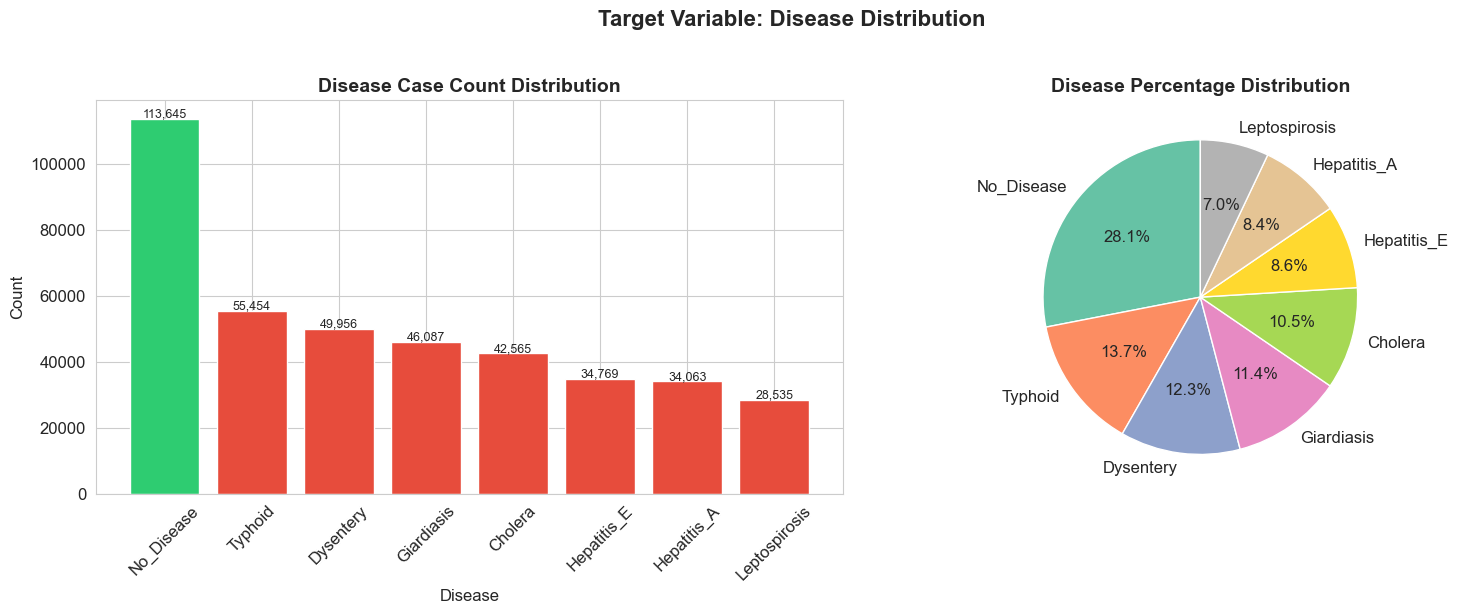

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart 
colors = ['#e74c3c' if d != 'No_Disease' else '#2ecc71' for d in disease_counts.index]
axes[0].bar(disease_counts.index, disease_counts.values, color=colors, edgecolor='white')
axes[0].set_title('Disease Case Count Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Disease')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

for i, (idx, val) in enumerate(disease_counts.items()):
    axes[0].text(i, val+500, f'{val:,}', ha='center', fontsize = 9)

# Pie chart
axes[1].pie(disease_counts.values, labels=disease_counts.index,
            autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('Set2', len(disease_counts)))
axes[1].set_title('Disease Percentage Distribution', fontsize=14, fontweight='bold')

plt.suptitle('Target Variable: Disease Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/01_disease_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Insight
- `disease` has 8 unique classes — **No_Disease dominates** with 113,645 records (28.1%), while **Leptospirosis has the least** with 28,535 records (7.0%).
- `disease` — **Typhoid is the most common disease** with 55,454 records (13.7%), followed by Dysentery (49,956) and Giardiasis (46,087).
- `disease` — **Waterborne diseases account for a significant share of cases**, with Typhoid, Dysentery, Giardiasis, and Cholera contributing nearly 48% of all records.
- `disease` — The maximum-to-minimum class ratio is **3.98x**, indicating **moderate class imbalance** but no severely underrepresented disease class.
- `disease` — Disease classes are reasonably well distributed, making the dataset suitable for **multiclass classification modeling**.

## 5. Geographic Analysis

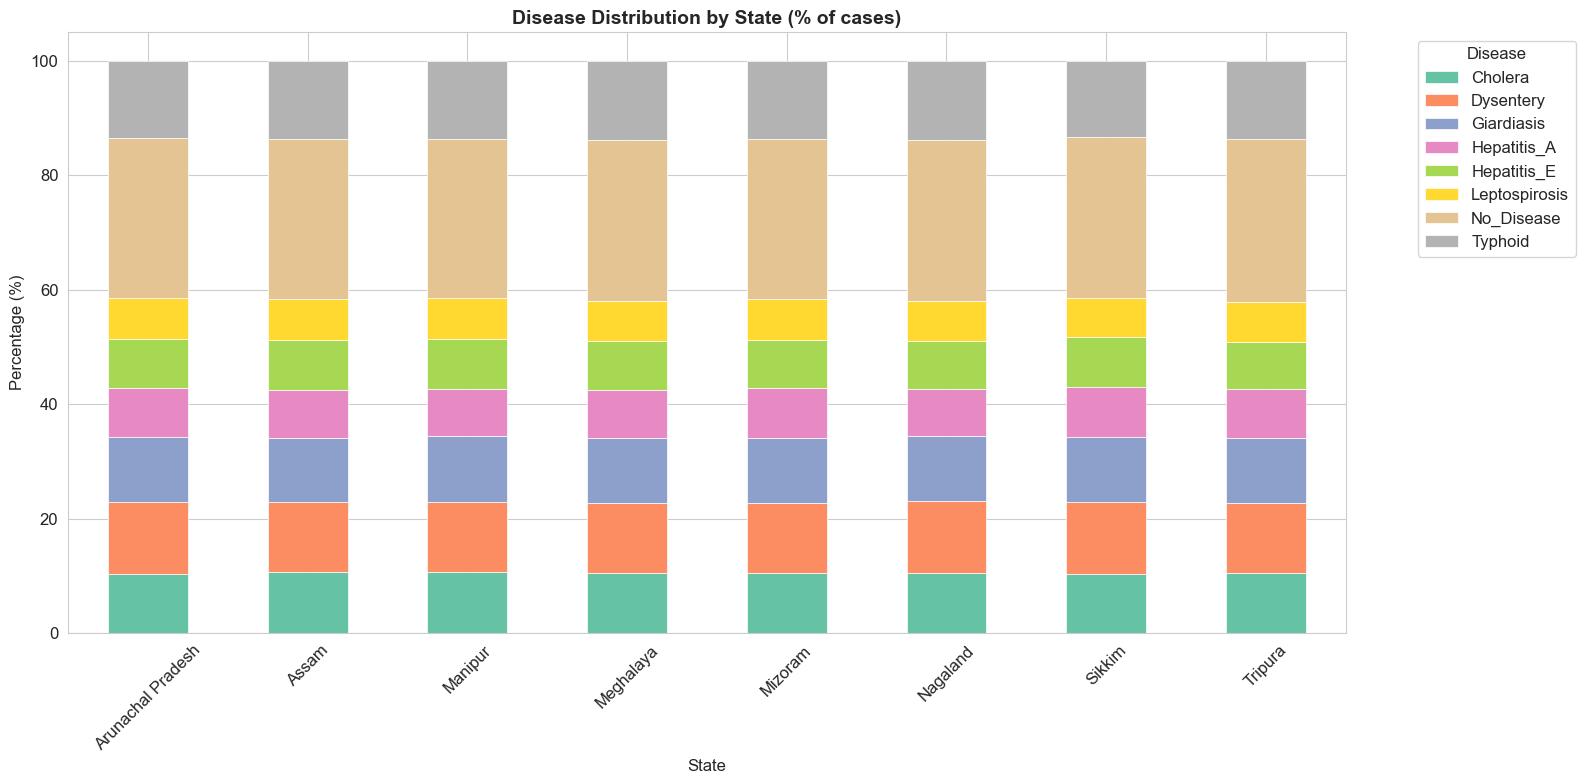

In [6]:
import os
os.makedirs('plots', exist_ok=True)

# State-wise disease distribution
state_disease = data.groupby(['state', 'disease']).size().unstack(fill_value=0)
state_disease_pct = state_disease.div(state_disease.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(16, 8))
state_disease_pct.plot(kind='bar', stacked=True, ax=ax,
                        colormap='Set2', edgecolor='white', linewidth=0.5)
ax.set_title('Disease Distribution by State (% of cases)', fontsize=14, fontweight='bold')
ax.set_xlabel('State')
ax.set_ylabel('Percentage (%)')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Disease', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('plots/02_state_disease_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Insight
- Disease distribution is **almost identical across all 8 states** — every state shows the same proportional breakdown of diseases.
- This tells us **state alone is NOT a strong predictor** of disease type — the model won't learn much from the `state` column by itself.
- **No_Disease (tan/beige) dominates every state** at ~28%, confirming consistent class imbalance across geography.
- **Dysentery, Giardiasis, Hepatitis_A, Hepatitis_E, Leptospirosis, Cholera, Typhoid** all appear in roughly equal proportions across states — disease burden is uniformly distributed geographically.
- This uniformity strongly suggests that **water quality, sanitation, and climate features** (not geography) are the real drivers of disease — which is exactly what we want for a generalizable ML model.
- **Implication for modeling**: `state` and `district` can likely be **dropped** without hurting model performance — lat/lon and water quality features carry the actual signal.

=== DISEASE CASES PER STATE (excluding No_Disease) ===
state
Assam                69596
Arunachal Pradesh    44944
Nagaland             38161
Meghalaya            37960
Manipur              31272
Mizoram              27872
Tripura              27631
Sikkim               13993
Name: count, dtype: int64


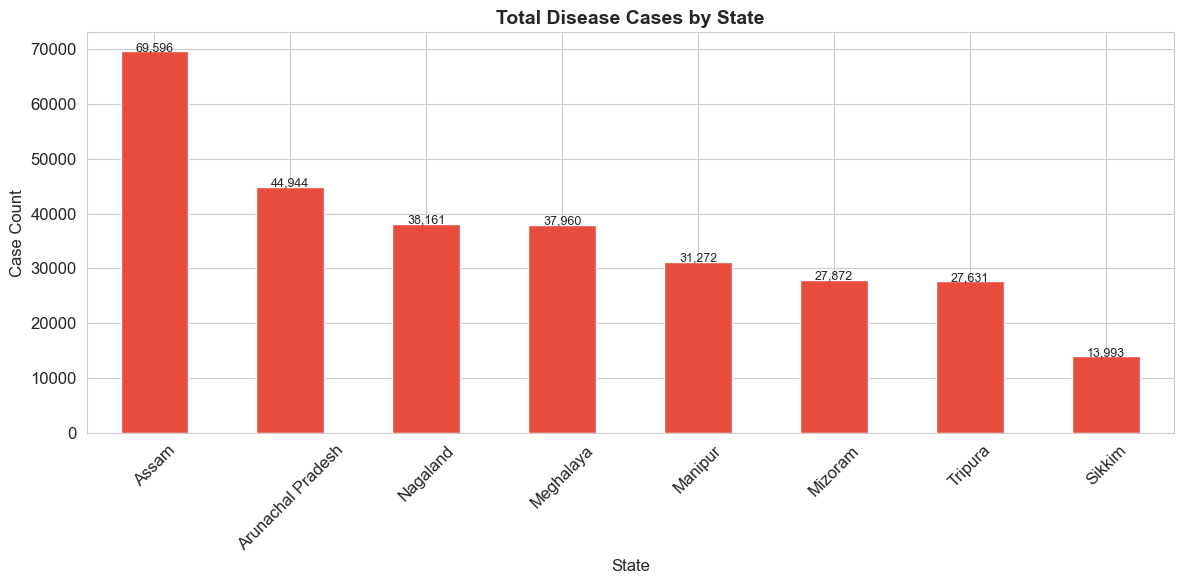

In [7]:
# Total cases per state
state_cases = data[data['disease'] != 'No_Disease']['state'].value_counts()
print('=== DISEASE CASES PER STATE (excluding No_Disease) ===')
print(state_cases)

fig, ax = plt.subplots(figsize=(12, 6))
state_cases.plot(kind='bar', color='#e74c3c', ax=ax, edgecolor='white')
ax.set_title('Total Disease Cases by State', fontsize=14, fontweight='bold')
ax.set_xlabel('State')
ax.set_ylabel('Case Count')
ax.tick_params(axis='x', rotation=45)
for i, val in enumerate(state_cases.values):
    ax.text(i, val + 100, f'{val:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('plots/03_cases_by_state.png', dpi=150, bbox_inches='tight')
plt.show()

### Insight
- **Assam has the highest disease burden (69,596 cases)** — nearly 5x more than Sikkim and ~1.5x more than Arunachal Pradesh. Directly reflects Assam's larger population (96,559 records in dataset).
- **Sikkim has the lowest case count (13,993)** — smallest population in the dataset (19,459 records), consistent with it being India's least populous state.
- However, when compared with the previous stacked bar chart, **disease proportions are identical across states** — meaning Assam's higher raw count is purely due to population size, not higher disease risk per capita.
- **Implication**: Raw case count differences between states are population-driven, not risk-driven. This further confirms `state` is a weak predictor and should likely be **dropped** from the feature set before modeling.

In [8]:
# Geographic scatter — disease hotspots
disease_only = data[data['disease'] != 'No_Disease'].sample(n=min(10000, len(data)), random_state=42)

fig = px.scatter_mapbox(
    disease_only,
    lat='latitude', lon='longitude',
    color='disease',
    hover_data=['state', 'district', 'disease'],
    mapbox_style='open-street-map',
    zoom=5, center={'lat': 25.5, 'lon': 93.0},
    title='Disease Hotspots Across Northeast India',
    opacity=0.6,
    height=600
)
fig.show()

## 6. Seasonal & Climate Analysis

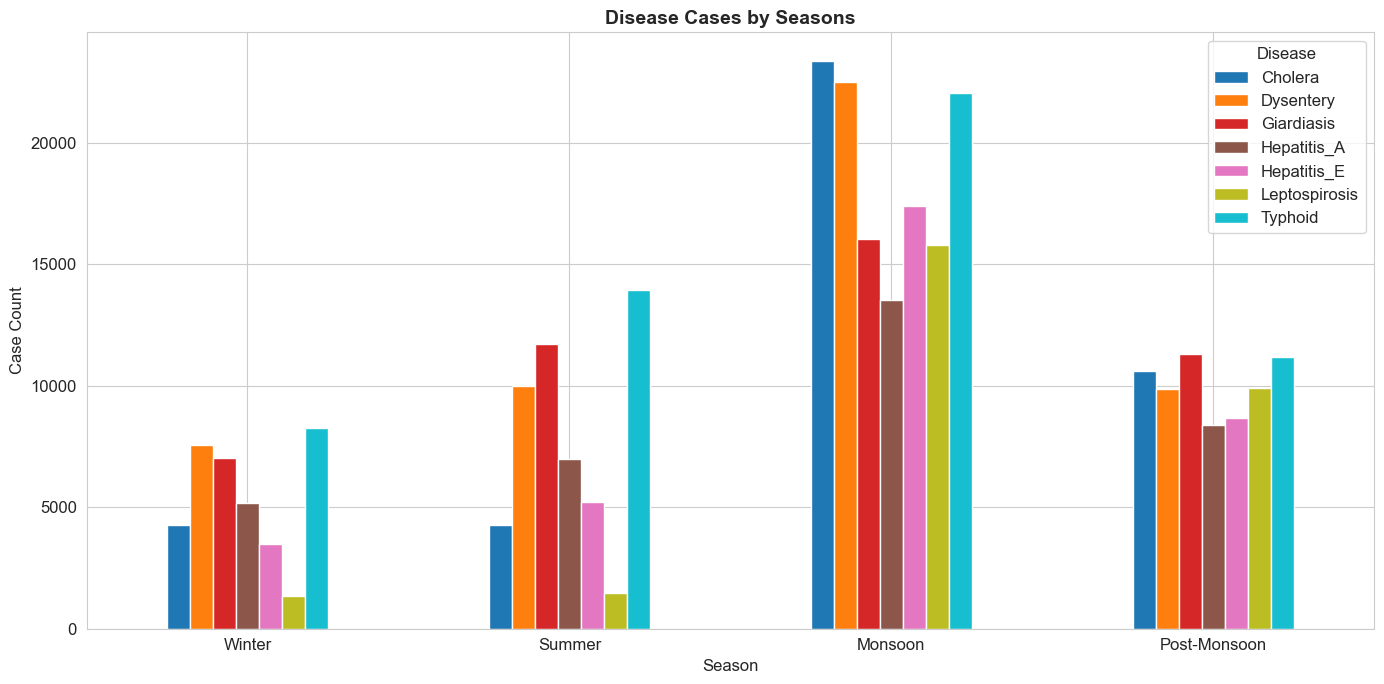

In [9]:
season_disease = data[data['disease'] != 'No_Disease'].groupby(['season', 'disease']).size().unstack(fill_value=0)
season_order = ['Winter', 'Summer', 'Monsoon', 'Post-Monsoon']
season_disease = season_disease.reindex(season_order)

fig, ax = plt.subplots(figsize=(14, 7))
season_disease.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='white')
ax.set_title("Disease Cases by Seasons", fontsize=14, fontweight='bold')
ax.set_xlabel('Season')
ax.set_ylabel('Case Count')
ax.tick_params(axis='x', rotation = 0)
ax.legend(title='Disease')
plt.tight_layout()
plt.savefig('plots/04_disease_by_season.png', dpi=150, bbox_inches='tight')
plt.show()

### Insight
- **Monsoon season drives the highest burden across ALL disease types** — every disease peaks during monsoon, confirming rainfall and flooding as the primary environmental trigger.
- **Cholera and Dysentery spike most sharply in Monsoon** (23,000+ and 22,000+ cases) compared to Winter (~4,000 each) — a ~5x seasonal surge, directly linked to contaminated floodwater.
- **Typhoid is uniquely high in Summer (14,000)** compared to other diseases in the same season — suggesting heat-driven water contamination as an additional pathway beyond flooding.
- **Leptospirosis is nearly absent in Winter and Summer** but jumps in Monsoon (~16,000) — consistent with its known transmission through flood water and soil contact.
- **Hepatitis_A and Hepatitis_E remain relatively low across all seasons** compared to Cholera/Dysentery/Typhoid — suggesting fecal-oral route is less dominant than direct water contamination in this region.
- **Post-Monsoon still shows elevated cases** for all diseases — waterborne risk doesn't drop immediately after monsoon ends, contamination persists in water sources.
- **Implication for modeling**: `season` and `month` are strong predictive features — keep both, apply cyclical encoding to `month`.

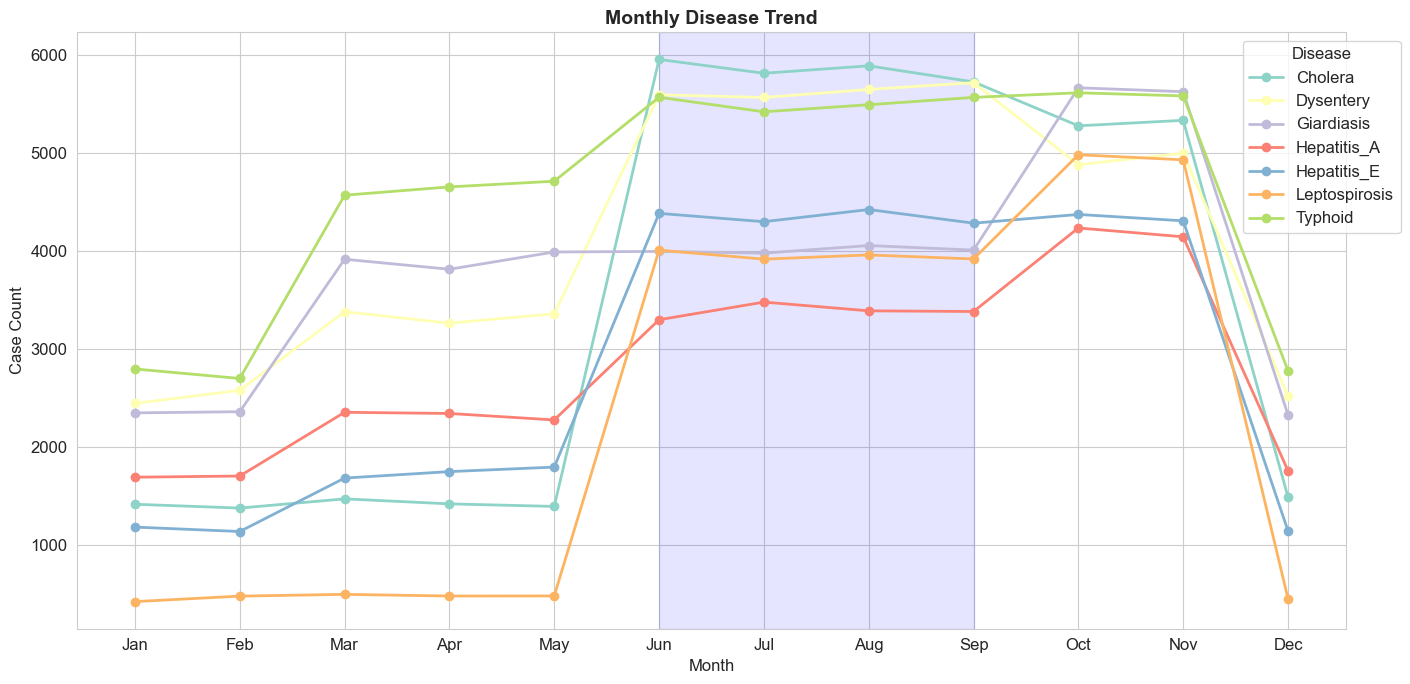

In [10]:
# Monthly disease trend
month_disease = data[data['disease'] != 'No_Disease'].groupby(['month', 'disease']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(16, 7))
for col in month_disease.columns:
    ax.plot(month_disease.index, month_disease[col], marker='o', label=col, linewidth=2)
ax.set_title('Monthly Disease Trend', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Case Count')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.legend(title='Disease', bbox_to_anchor=(1.05, 1))
ax.axvspan(6, 9, alpha=0.1, color='blue', label='Monsoon')
plt.tight_layout()
plt.savefig('plots/05_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

### Insight
- **All diseases follow a clear seasonal curve** — low in Jan–May, sharp spike in Jun–Sep (monsoon), gradual decline in Oct–Dec. `month` is a strong predictive feature.
- **Cholera and Typhoid peak hardest in June** (~6,000 cases each) — the first monsoon month triggers immediate waterborne contamination.
- **Leptospirosis shows the most dramatic pattern** — near zero (400–500 cases) from Jan–May, then explodes in Jun–Sep (~4,000+). Most seasonally dependent disease in the dataset, directly linked to flood water contact.
- **Typhoid starts rising early in March** (~4,500) before other diseases — suggesting heat-driven contamination begins pre-monsoon, consistent with Summer Typhoid pattern seen in the previous chart.
- **Giardiasis (purple) stays relatively flat** year-round compared to others — less monsoon-dependent, more linked to chronic poor water quality.
- **December shows a sharp cliff drop for all diseases** — particularly Leptospirosis drops to near zero, confirming flooding as its sole transmission driver.

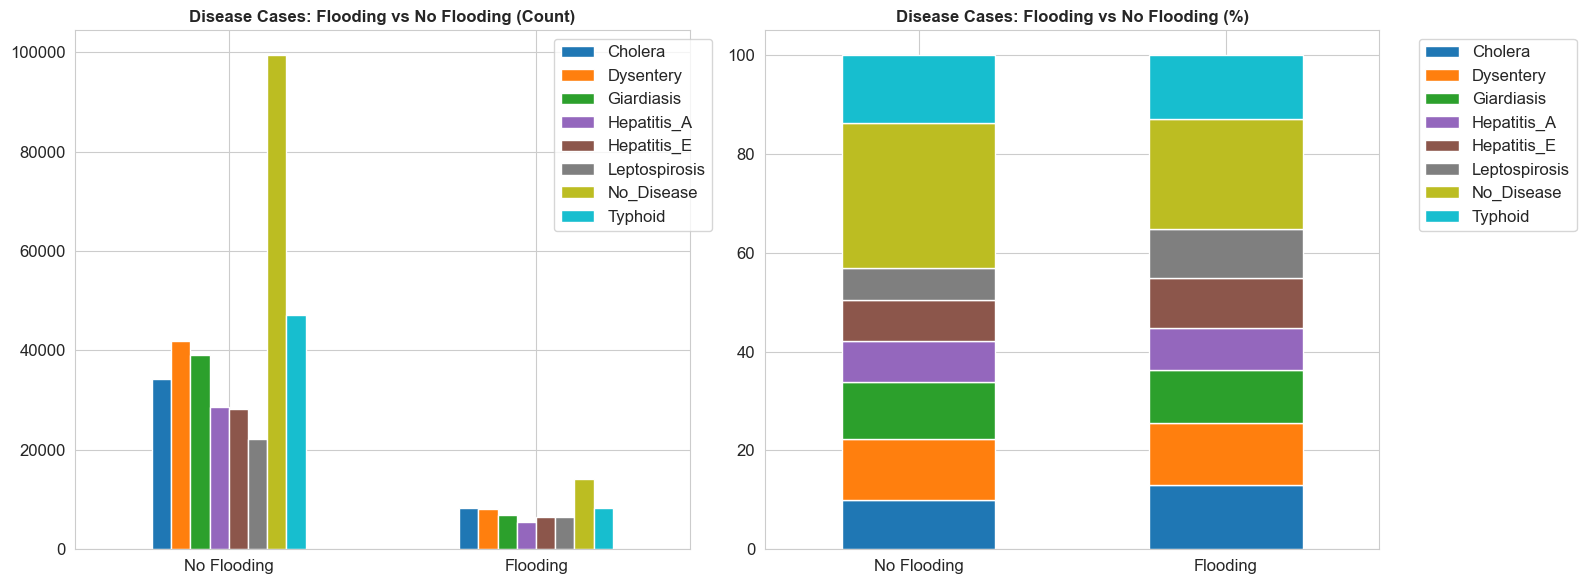

In [11]:
# Flooding impact
flooding_disease = data.groupby(['flooding', 'disease']).size().unstack(fill_value=0)
flooding_disease.index = ['No Flooding', 'Flooding']
flooding_pct = flooding_disease.div(flooding_disease.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
flooding_disease.plot(kind='bar', ax=axes[0], colormap='tab10', edgecolor='white')
axes[0].set_title('Disease Cases: Flooding vs No Flooding (Count)', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(bbox_to_anchor=(1.05, 1))

flooding_pct.plot(kind='bar', stacked=True, ax=axes[1], colormap='tab10', edgecolor='white')
axes[1].set_title('Disease Cases: Flooding vs No Flooding (%)', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.savefig('plots/06_flooding_impact.png', dpi=150, bbox_inches='tight')
plt.show()

### Insight
- **Flooding records are significantly fewer** than No Flooding — flooding is a relatively rare event in the dataset but has a disproportionate disease impact.
- **No_Disease drops sharply during flooding** — from ~85% in No Flooding to ~65% in Flooding (right chart). Flooding directly increases disease probability.
- **Leptospirosis proportion jumps most dramatically during flooding** — from a small grey band in No Flooding to a much larger band in Flooding. Confirms flooding as its primary transmission mechanism.
- **Cholera proportion also increases during flooding** — rises from ~10% to ~13% of all cases, consistent with floodwater contaminating drinking sources.
- **Dysentery, Giardiasis, Hepatitis_A/E** show modest increases during flooding — all waterborne routes amplified by flood contamination.
- **Typhoid proportion slightly decreases during flooding** — suggesting Typhoid is more heat/sanitation driven than flood driven, consistent with its Summer peak observed earlier.

## 7. Water Quality Analysis

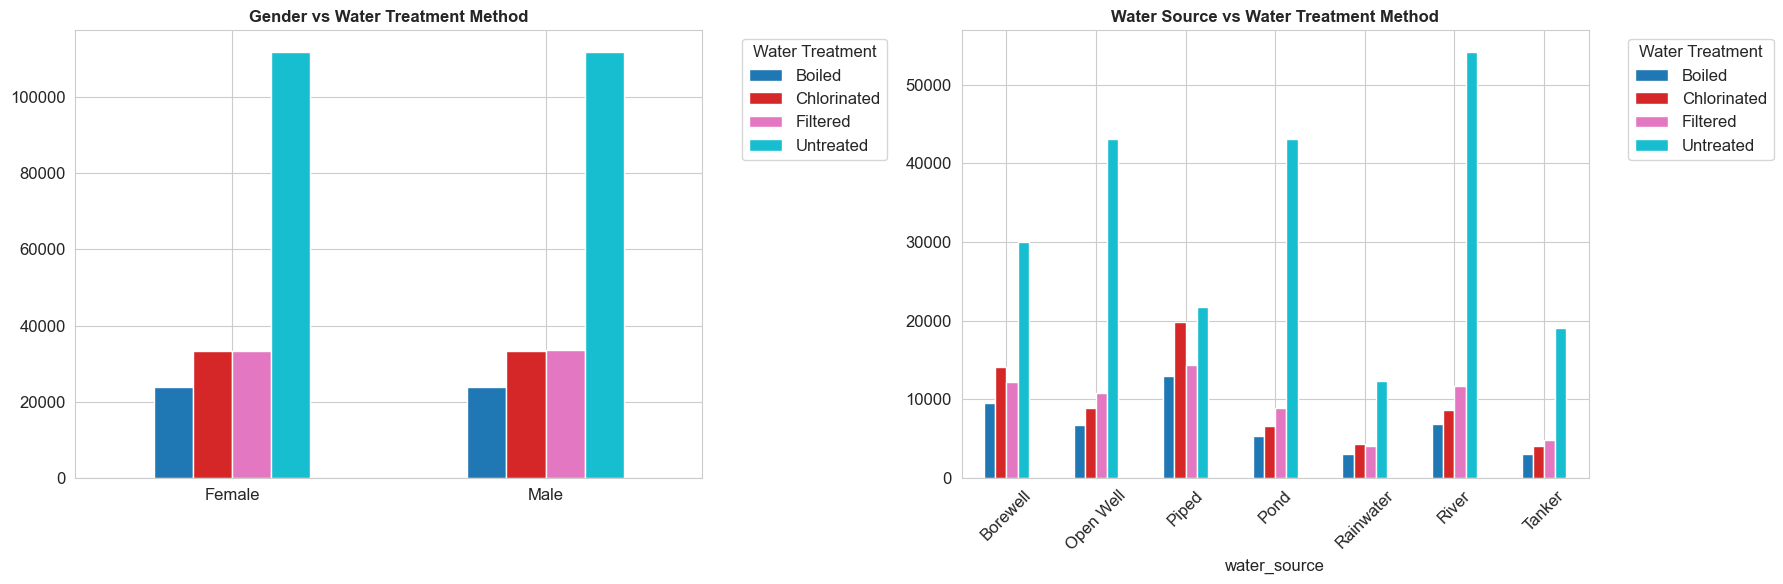

In [20]:
water_gen = data.groupby(['gender', 'water_treatment']).size().unstack(fill_value=0)
water_gen.index = ['Female', 'Male']

water_source = data.groupby(['water_source', 'water_treatment']).size().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1 — Gender vs Water Treatment
water_gen.plot(kind='bar', ax=axes[0], colormap='tab10', edgecolor='white')
axes[0].set_title('Gender vs Water Treatment Method', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Water Treatment', bbox_to_anchor=(1.05, 1))

# Plot 2 — Water Source vs Water Treatment
water_source.plot(kind='bar', ax=axes[1], colormap='tab10', edgecolor='white')
axes[1].set_title('Water Source vs Water Treatment Method', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Water Treatment', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.savefig('plots/07_water_gender_source.png', dpi=150, bbox_inches='tight')
plt.show()

### Insight
- **Gender vs Water Treatment (left)**: Distribution is almost identical between Female and Male across all treatment methods — gender has no influence on water treatment access. `gender` is likely a weak predictor and may be dropped.
- **Untreated water dominates both genders** (~110,000 each) — more than 3x any other treatment method, confirming the majority of the population consumes untreated water regardless of gender.
- **Water Source vs Water Treatment (right)**: **River has the highest Untreated usage (~55,000)** — the most dangerous combination since river water carries the highest pathogen load with zero treatment.
- **Open Well and Pond also show very high Untreated counts** (~43,000 each) — both stagnant/surface water sources with no treatment is the worst-case scenario for waterborne disease.
- **Piped water shows the most balanced treatment distribution** — Chlorinated and Filtered are relatively higher here, as expected since piped systems are more likely to have treatment infrastructure.
- **Rainwater has the lowest overall usage** but still shows significant Untreated consumption — collected rainwater without treatment remains a risk.

=== PEOPLE BY WATER SOURCE ===
water_source
River        81550
Open Well    69510
Piped        68993
Borewell     65879
Pond         64113
Tanker       31077
Rainwater    23952
Name: count, dtype: int64

=== DISEASE RATE BY WATER SOURCE (%) ===
disease       Cholera  Dysentery  Giardiasis  Hepatitis_A  Hepatitis_E  \
water_source                                                             
Borewell         6.46       9.11       10.59         7.66         6.30   
Open Well        9.06      16.08       16.66         9.91         9.77   
Piped            2.93       5.64        6.68         4.95         3.91   
Pond            13.69      13.88       18.02        10.48        11.08   
Rainwater        8.65      10.16        9.34         7.38         7.44   
River           18.24      15.40        8.43         8.38        10.81   
Tanker          13.73      16.10        7.27        10.92        11.03   

disease       Leptospirosis  No_Disease  Typhoid  
water_source                         

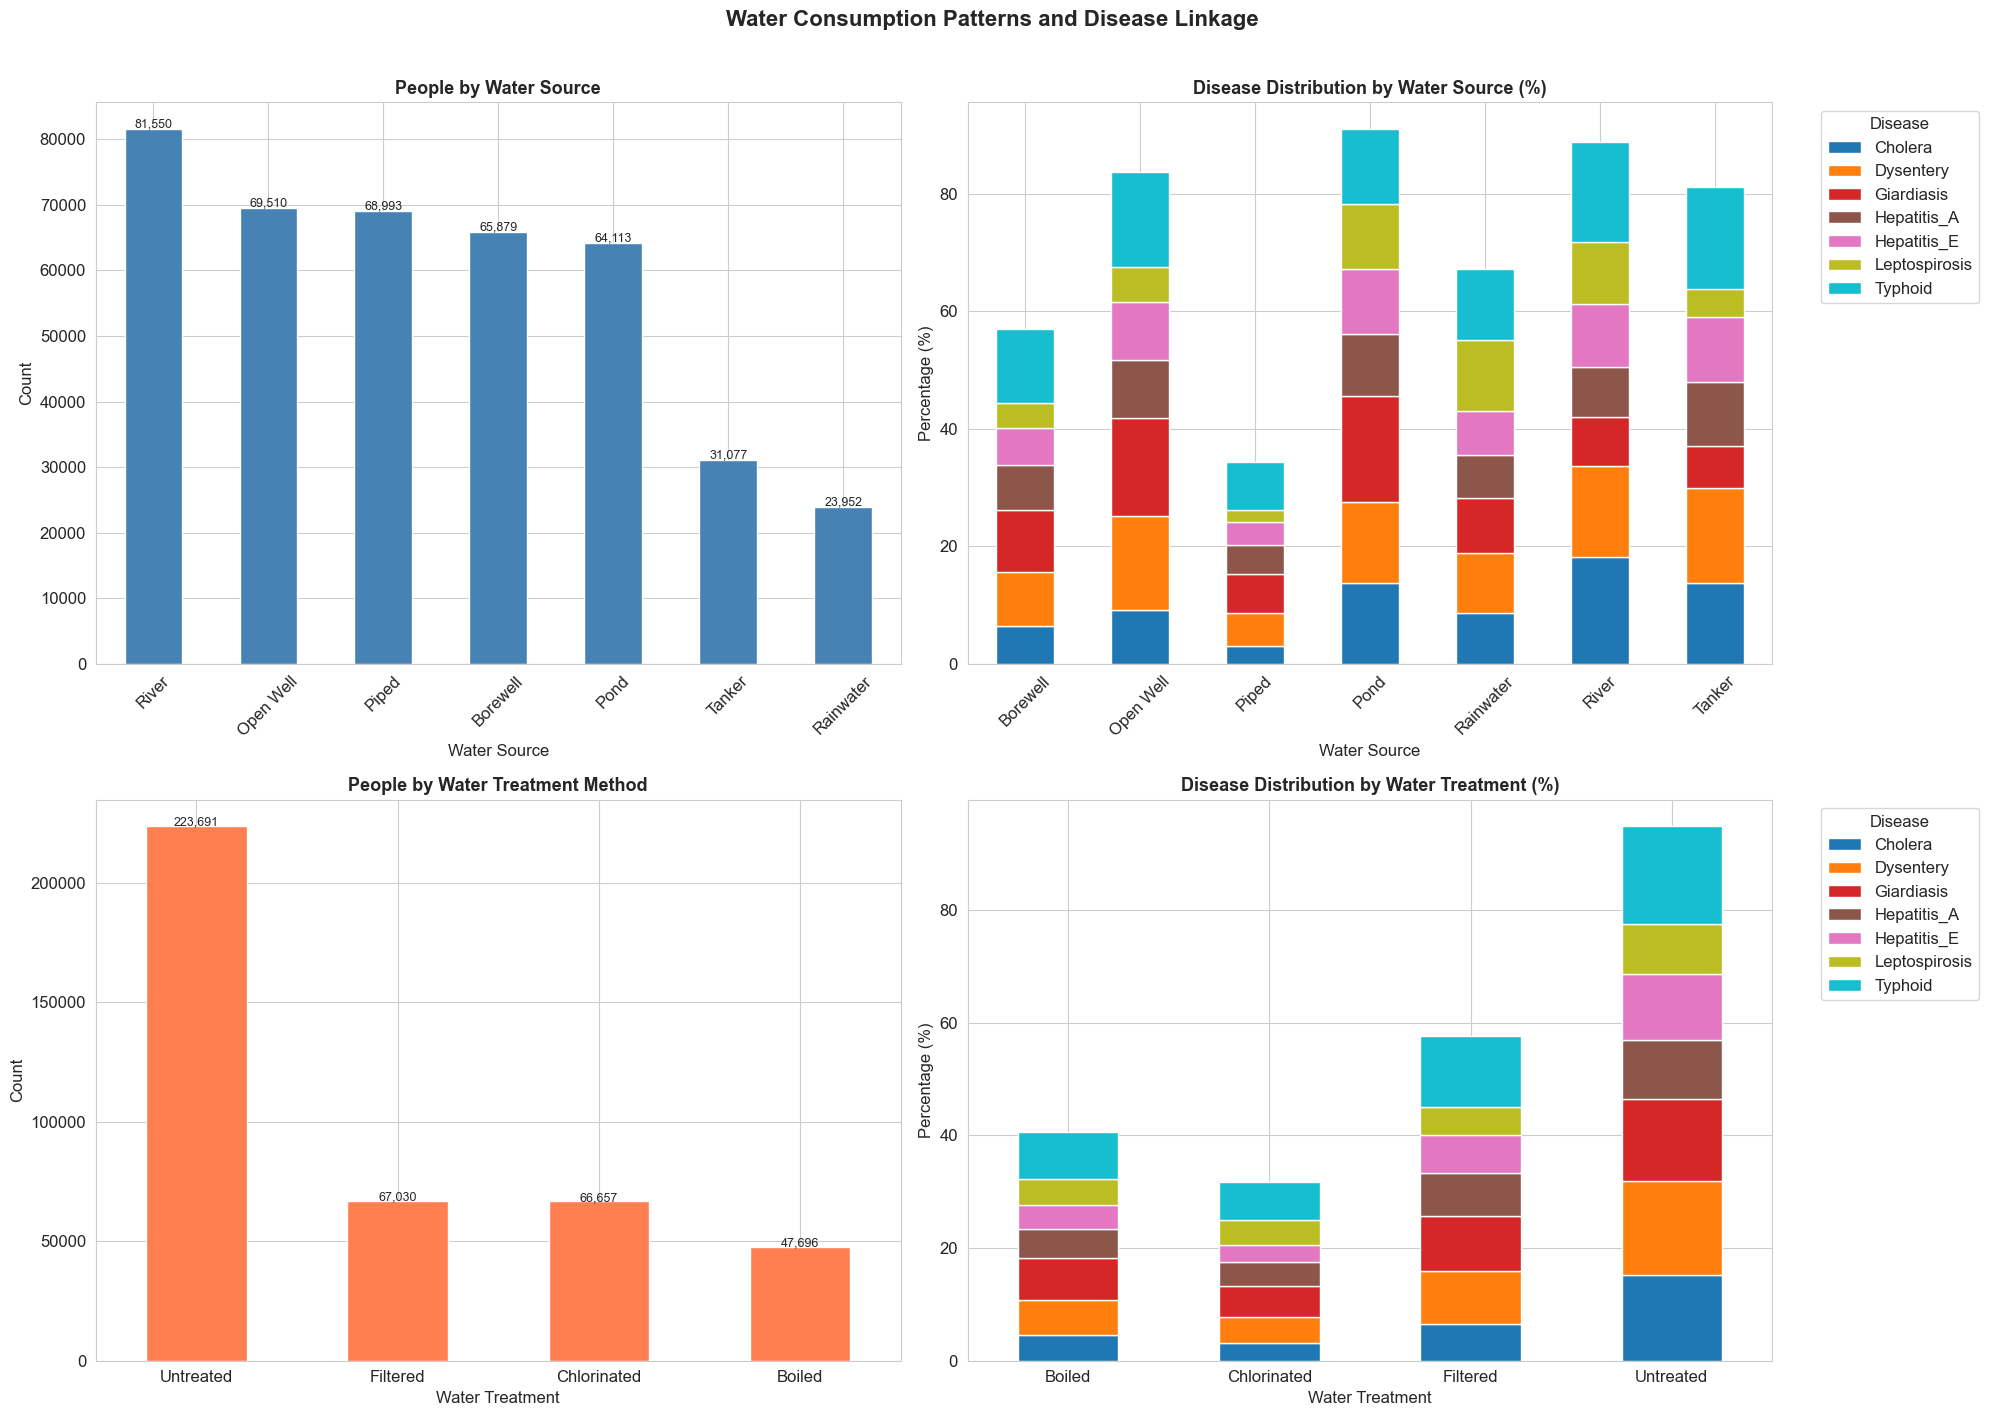

In [21]:
# Water Source → Disease mapping
water_disease = data.groupby(['water_source', 'disease']).size().unstack(fill_value=0)
water_disease_pct = water_disease.div(water_disease.sum(axis=1), axis=0) * 100

# Water Treatment → Disease mapping
treatment_disease = data.groupby(['water_treatment', 'disease']).size().unstack(fill_value=0)
treatment_disease_pct = treatment_disease.div(treatment_disease.sum(axis=1), axis=0) * 100

print('=== PEOPLE BY WATER SOURCE ===')
print(data['water_source'].value_counts())

print('\n=== DISEASE RATE BY WATER SOURCE (%) ===')
print(water_disease_pct.round(2))

print('\n=== PEOPLE BY WATER TREATMENT ===')
print(data['water_treatment'].value_counts())

print('\n=== DISEASE RATE BY WATER TREATMENT (%) ===')
print(treatment_disease_pct.round(2))

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# Plot 1 — Water Source count
data['water_source'].value_counts().plot(kind='bar', ax=axes[0][0], 
                                          color='steelblue', edgecolor='white')
axes[0][0].set_title('People by Water Source', fontsize=13, fontweight='bold')
axes[0][0].set_xlabel('Water Source')
axes[0][0].set_ylabel('Count')
axes[0][0].tick_params(axis='x', rotation=45)
for i, val in enumerate(data['water_source'].value_counts()):
    axes[0][0].text(i, val + 300, f'{val:,}', ha='center', fontsize=9)

# Plot 2 — Water Source vs Disease (%)
water_disease_pct.drop(columns='No_Disease', errors='ignore').plot(
    kind='bar', stacked=True, ax=axes[0][1], colormap='tab10', edgecolor='white')
axes[0][1].set_title('Disease Distribution by Water Source (%)', fontsize=13, fontweight='bold')
axes[0][1].set_xlabel('Water Source')
axes[0][1].set_ylabel('Percentage (%)')
axes[0][1].tick_params(axis='x', rotation=45)
axes[0][1].legend(title='Disease', bbox_to_anchor=(1.05, 1))

# Plot 3 — Water Treatment count
data['water_treatment'].value_counts().plot(kind='bar', ax=axes[1][0],
                                             color='coral', edgecolor='white')
axes[1][0].set_title('People by Water Treatment Method', fontsize=13, fontweight='bold')
axes[1][0].set_xlabel('Water Treatment')
axes[1][0].set_ylabel('Count')
axes[1][0].tick_params(axis='x', rotation=0)
for i, val in enumerate(data['water_treatment'].value_counts()):
    axes[1][0].text(i, val + 300, f'{val:,}', ha='center', fontsize=9)

# Plot 4 — Water Treatment vs Disease (%)
treatment_disease_pct.drop(columns='No_Disease', errors='ignore').plot(
    kind='bar', stacked=True, ax=axes[1][1], colormap='tab10', edgecolor='white')
axes[1][1].set_title('Disease Distribution by Water Treatment (%)', fontsize=13, fontweight='bold')
axes[1][1].set_xlabel('Water Treatment')
axes[1][1].set_ylabel('Percentage (%)')
axes[1][1].tick_params(axis='x', rotation=0)
axes[1][1].legend(title='Disease', bbox_to_anchor=(1.05, 1))

plt.suptitle('Water Consumption Patterns and Disease Linkage', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plots/08_water_disease_linkage.png', dpi=150, bbox_inches='tight')
plt.show()

### Insight

**People by Water Source:**
- **River is the most used source (81,550 people)** despite being the highest risk — Open Well (69,510), Piped (68,993), Borewell (65,879), and Pond (64,113) follow closely.
- **Rainwater (23,952) and Tanker (31,077) are least used** — limited availability in remote NE districts.

**Disease Rate by Water Source:**
- **Piped water users have the lowest disease rate** — 65.73% No_Disease, confirming piped as the safest source.
- **River water drives the highest Cholera rate (18.24%)** — floodwater contamination of rivers is the primary Cholera pathway.
- **Pond water has the highest Giardiasis rate (18.02%)** — stagnant pond water is a breeding ground for Giardia parasites.
- **Rainwater users show surprisingly high Leptospirosis (12.09%)** — collected rainwater may be contaminated by animal waste on rooftops.
- **Open Well has the highest Dysentery rate (16.08%)** — shallow open wells are easily contaminated by surface runoff.
- **Tanker water shows high Typhoid (17.51%)** — tanker water quality is unregulated and storage containers may be contaminated.

**People by Water Treatment:**
- **223,691 people (55%) drink Untreated water** — the single biggest public health risk factor in the dataset.

**Disease Rate by Water Treatment:**
- **Untreated water = 15.18% Cholera, 16.76% Dysentery, 17.30% Typhoid** — all dramatically higher than treated water.
- **Chlorinated water has the lowest overall disease rate** — only 6.73% Typhoid and 68.28% No_Disease, confirming chlorination as the most effective treatment.
- **Filtered water still shows 12.46% Typhoid** — filtration removes particles but not all pathogens, chemical treatment is needed.
- **Boiled water users have 59.44% No_Disease** — effective but less so than chlorination, possibly due to recontamination after boiling.

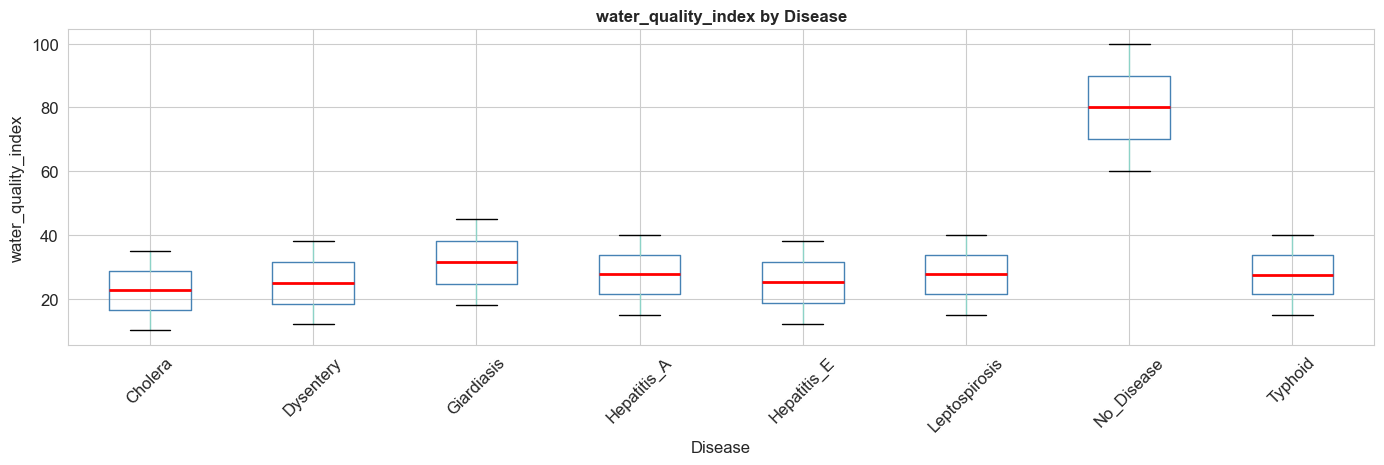

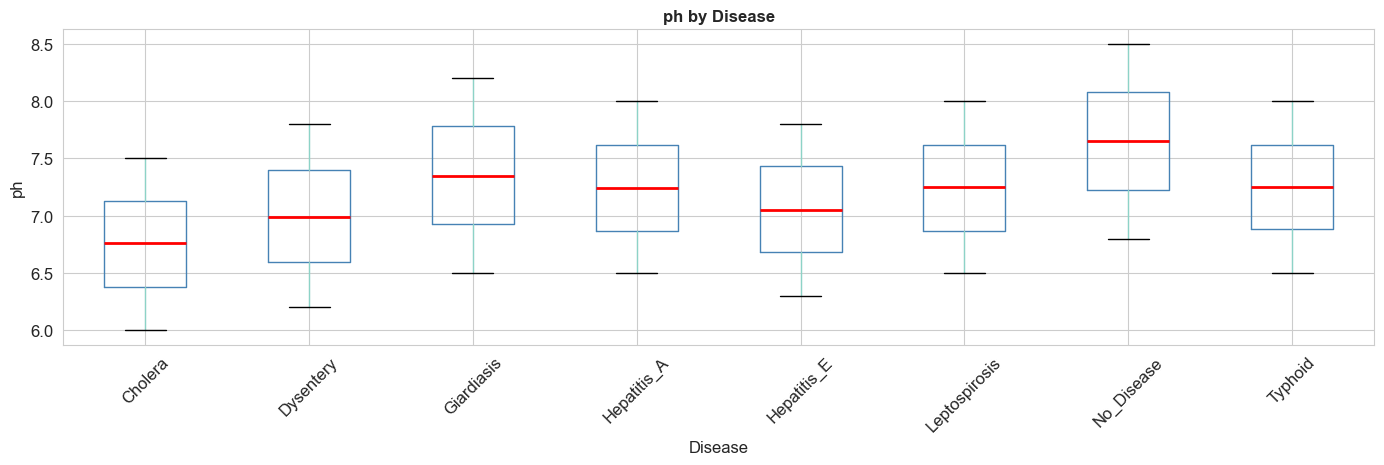

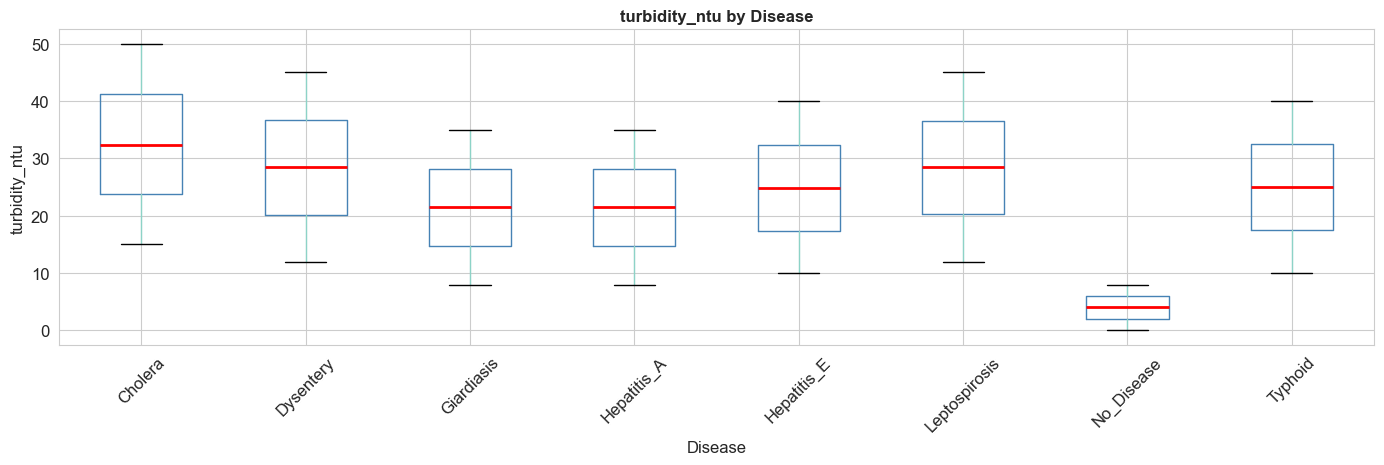

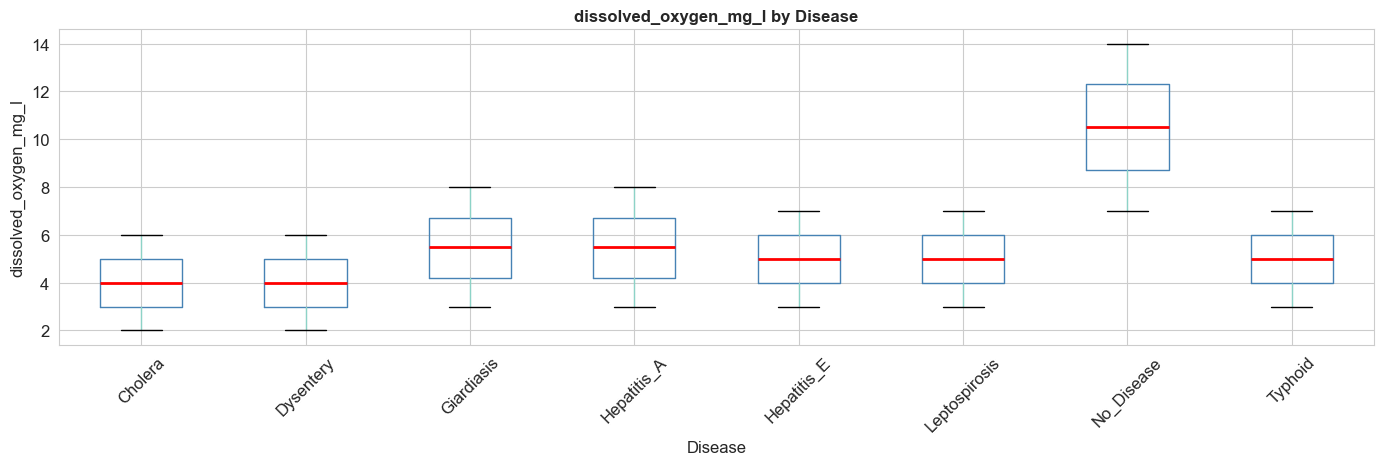

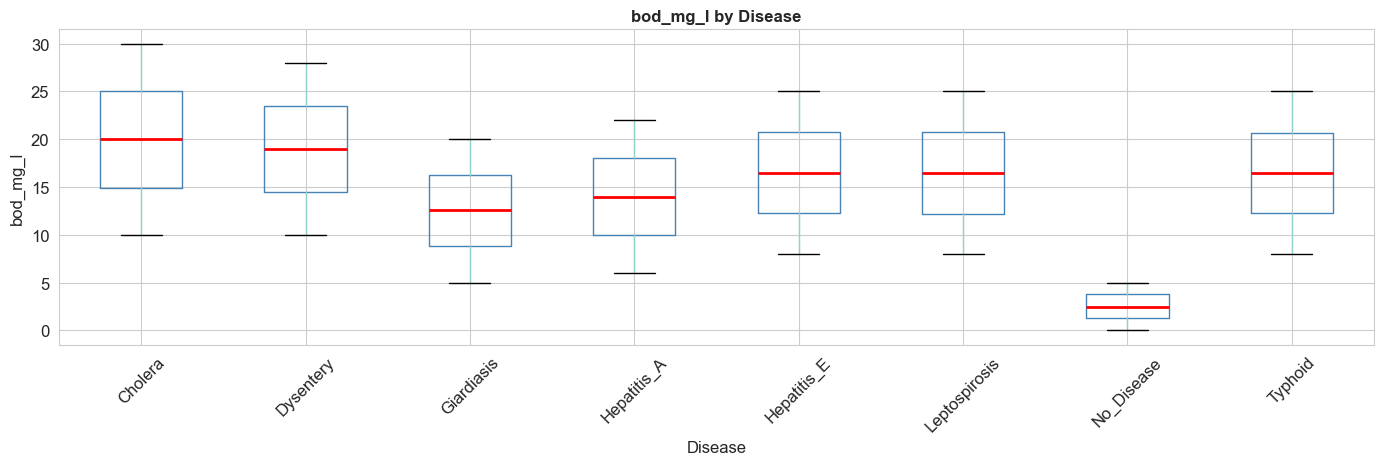

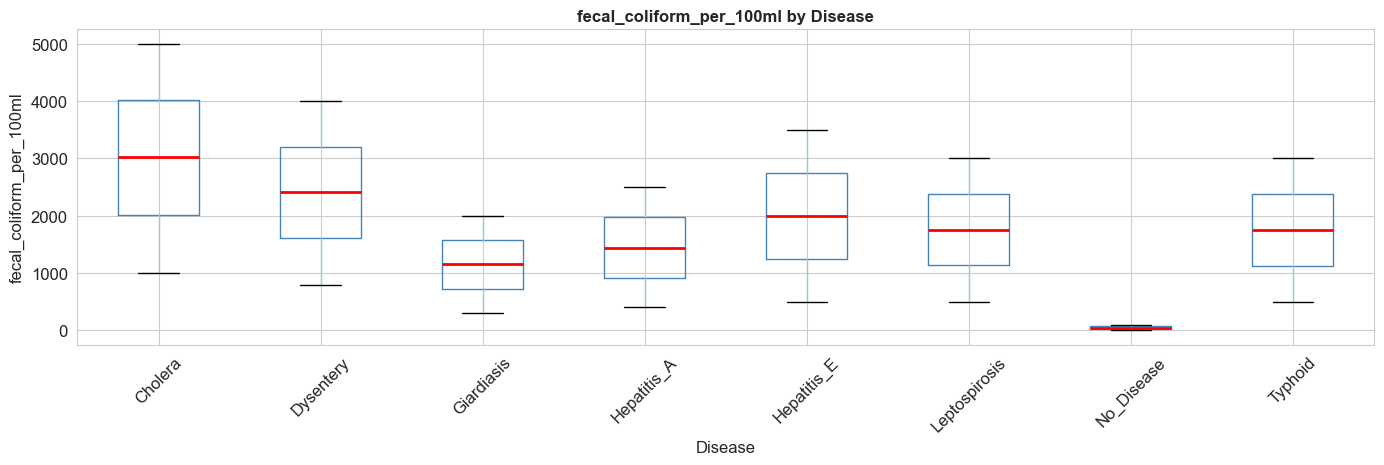

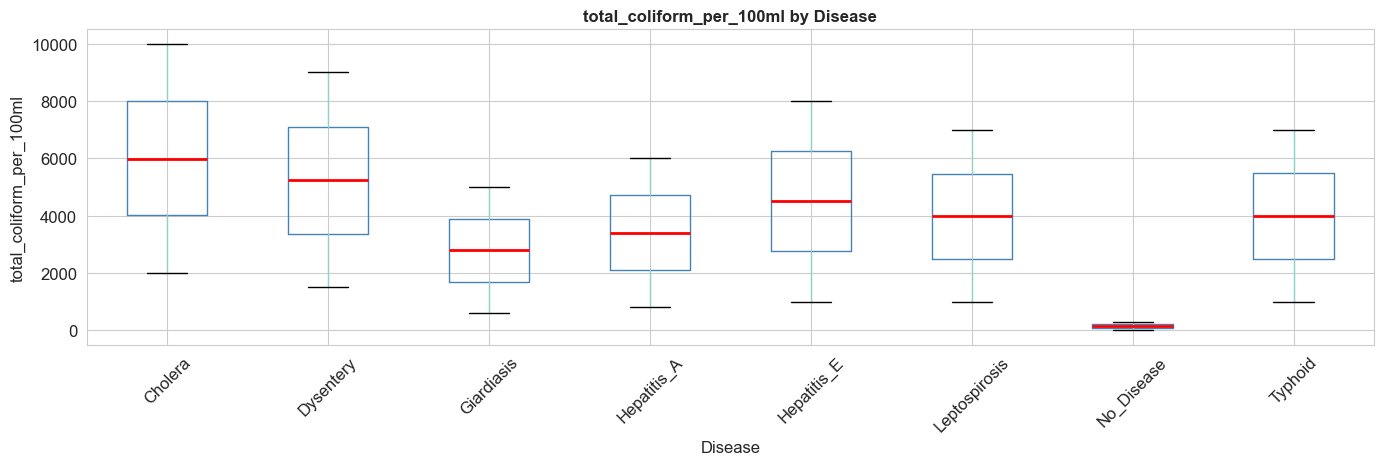

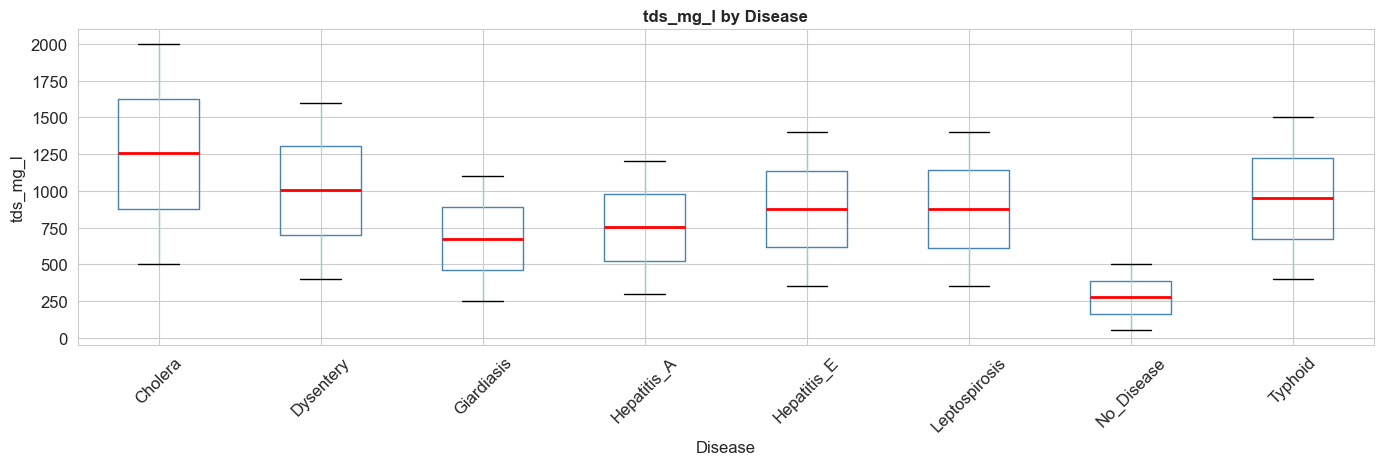

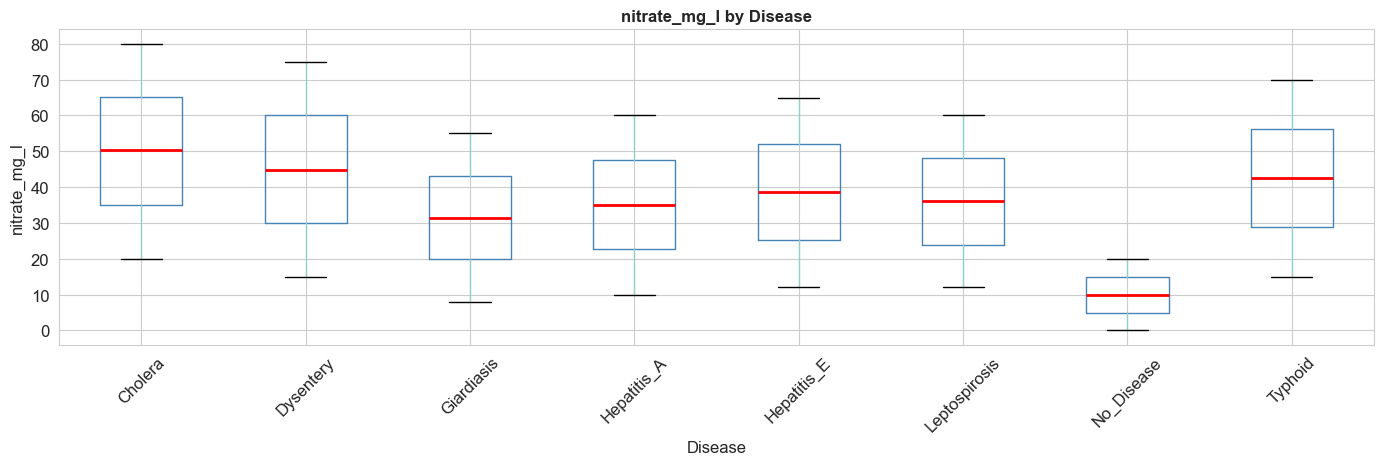

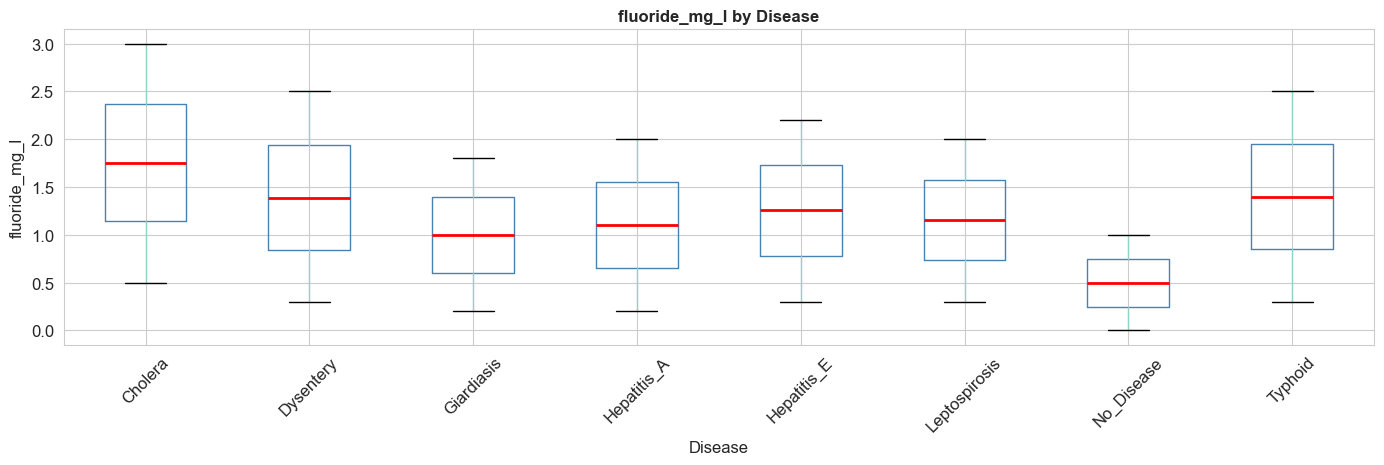

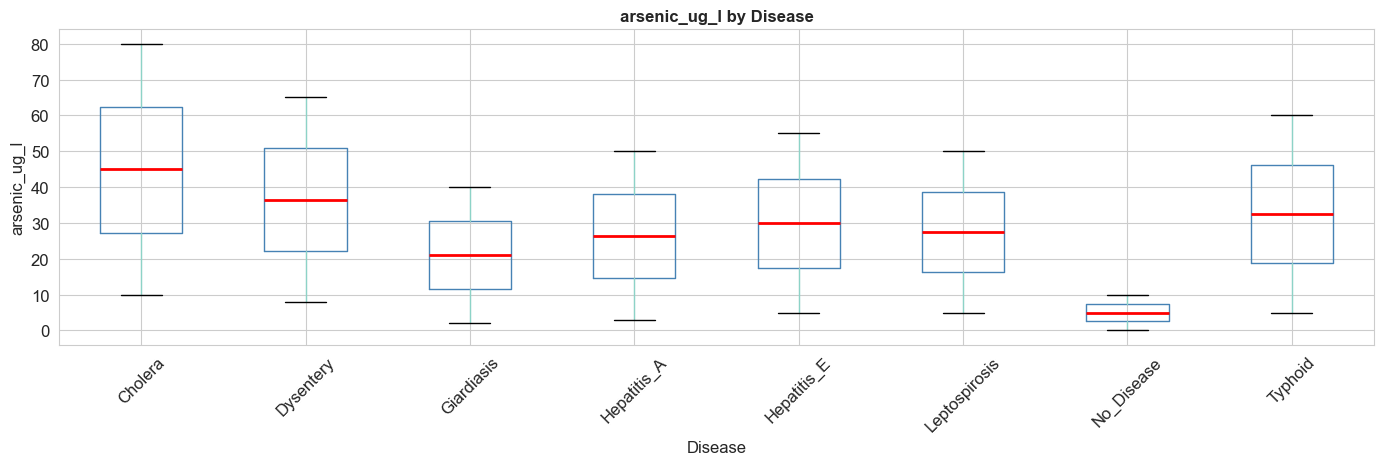

In [22]:
water_quality_cols = [
    'water_quality_index', 'ph', 'turbidity_ntu', 'dissolved_oxygen_mg_l',
    'bod_mg_l', 'fecal_coliform_per_100ml', 'total_coliform_per_100ml',
    'tds_mg_l', 'nitrate_mg_l', 'fluoride_mg_l', 'arsenic_ug_l'
]

# Box plots: water quality per disease
for col in water_quality_cols:
    fig, ax = plt.subplots(figsize=(14, 5))
    disease_order = data['disease'].value_counts().index.tolist()
    data.boxplot(column=col, by='disease', ax=ax, 
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(f'{col} by Disease', fontsize=12, fontweight='bold')
    ax.set_xlabel('Disease')
    ax.set_ylabel(col)
    plt.suptitle('')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f'plots/wq_{col}.png', dpi=120, bbox_inches='tight')
    plt.show()

### Insight — Water Quality Parameters by Disease

**Water Quality Index (WQI):**
- **No_Disease has WQI ~80** while all disease classes cluster between 20–35 — WQI is the single strongest separator between sick and healthy populations.
- **Cholera has the lowest WQI (~22)** — most contaminated water conditions of all diseases.
- **Implication**: `water_quality_index` will likely be the top feature in the model.

**pH:**
- **Cholera occurs at lowest pH (~6.8)** — acidic water conditions favour Vibrio cholerae survival.
- **No_Disease has highest pH (~7.6)** — near-neutral to slightly alkaline water is safer.
- All disease classes fall between 6.8–7.4, giving pH moderate discriminatory power.

**Turbidity:**
- **No_Disease has near-zero turbidity (~4 NTU)** vs all diseases ranging 20–35 NTU — clean water is visually clear.
- **Cholera has highest turbidity (~32 NTU)** — heavily cloudy water is the Cholera signature.
- **Strong feature** — turbidity alone clearly separates No_Disease from all disease classes.

**Dissolved Oxygen:**
- **No_Disease has dramatically higher DO (~10.5 mg/L)** vs all diseases (3.5–5.5 mg/L).
- **Cholera and Dysentery have lowest DO (~4 mg/L)** — oxygen-depleted water indicates heavy organic pollution and bacterial activity.
- **Top-tier discriminating feature** alongside WQI and turbidity.

**BOD (Biochemical Oxygen Demand):**
- **No_Disease BOD is near zero (~2.5)** while all diseases range 13–20 mg/L.
- **Cholera has highest BOD (~20)** — high organic matter load drives pathogen growth.
- Perfectly mirrors the dissolved oxygen pattern — high BOD depletes DO.

**Fecal Coliform:**
- **No_Disease median ~50 CFU/100ml** vs Cholera median ~3,000 and Dysentery ~2,500 — a 50–60x difference.
- **Most dramatic separator in the entire dataset** — fecal coliform count alone almost perfectly identifies disease vs no-disease.
- **Apply `np.log1p()` transform** before modeling — extreme right skew.

**Total Coliform:**
- Same pattern as fecal coliform — **No_Disease ~100** vs Cholera ~6,000, Dysentery ~5,000.
- Cholera and Dysentery have the highest bacterial loads confirming fecal-oral transmission route.
- **Apply `np.log1p()` transform** — even more right-skewed than fecal coliform.

**TDS (Total Dissolved Solids):**
- **No_Disease TDS ~250 mg/L** vs Cholera ~1,250 and Dysentery ~1,000 — 4–5x difference.
- High TDS indicates dissolved minerals and contaminants from sewage and industrial runoff.
- **Strong predictive feature**, apply StandardScaler before modeling.

**Nitrate:**
- **No_Disease nitrate ~10 mg/L** vs all diseases ranging 30–50 mg/L.
- **Cholera has highest nitrate (~50)** — agricultural runoff and sewage both contribute.
- Good discriminator between No_Disease and disease classes.

**Fluoride:**
- **No_Disease ~0.5 mg/L** vs Cholera ~1.8, Dysentery ~1.4 — moderate separation.
- Weaker predictor compared to coliform, DO, and turbidity but still useful.

**Arsenic:**
- **No_Disease ~5 µg/L** vs Cholera ~45, Dysentery ~35 — very strong separation.
- Arsenic contamination co-occurs with other water quality issues — acts as a proxy for overall contamination level.
- Northeast India (especially Assam) has known arsenic contamination in groundwater.

**Overall Implication:**
- **Top 5 water quality features for modeling**: `fecal_coliform_per_100ml`, `total_coliform_per_100ml`, `dissolved_oxygen_mg_l`, `water_quality_index`, `turbidity_ntu`
- Apply `np.log1p()` to fecal and total coliform before scaling — all others use StandardScaler.

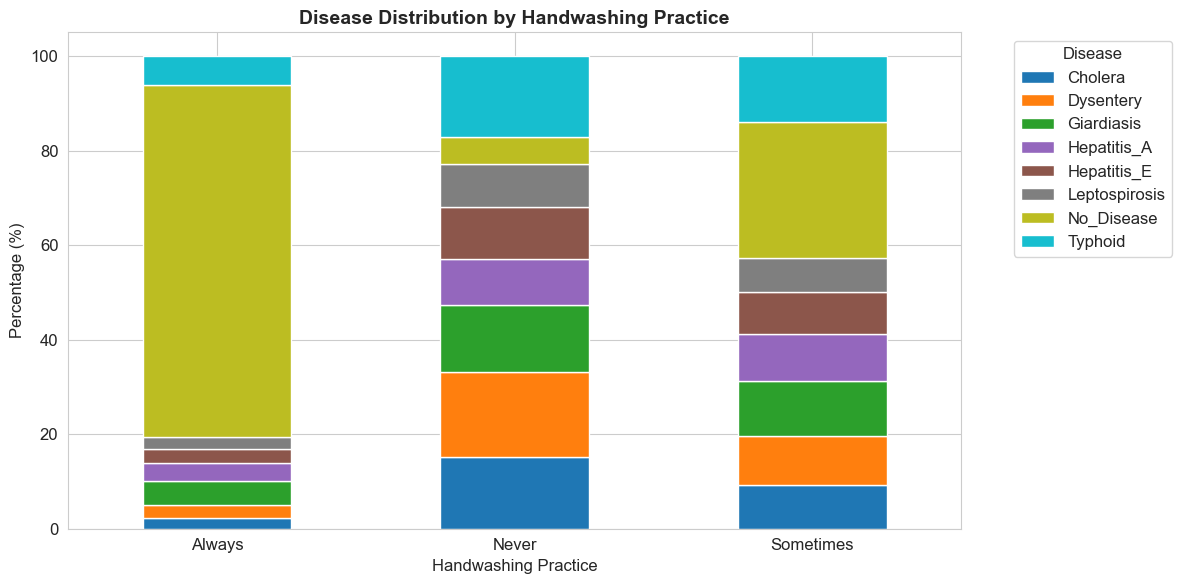

In [23]:
# Handwashing practice vs disease
hw_disease = data.groupby(['handwashing_practice', 'disease']).size().unstack(fill_value=0)
hw_pct = hw_disease.div(hw_disease.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 6))
hw_pct.plot(kind='bar', stacked=True, ax=ax, colormap='tab10', edgecolor='white')
ax.set_title('Disease Distribution by Handwashing Practice', fontsize=14, fontweight='bold')
ax.set_xlabel('Handwashing Practice')
ax.set_ylabel('Percentage (%)')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Disease', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig('plots/10_handwashing_disease.png', dpi=150, bbox_inches='tight')
plt.show()

### Insight
- **"Always" handwashing = ~93% No_Disease** — the single clearest behavioral intervention in the entire dataset. People who always wash hands are almost completely protected from waterborne diseases.
- **"Never" handwashing = only ~18% No_Disease** — meaning 82% of people who never wash hands contract a disease, the highest disease burden of any behavioral factor.
- **"Sometimes" handwashing = ~57% No_Disease** — falls exactly between Always and Never, confirming a clear dose-response relationship between handwashing frequency and disease risk.
- **Cholera and Dysentery dominate the "Never" group** (~15% and ~18% respectively) — fecal-oral transmission is directly prevented by handwashing, making this the most actionable public health insight from the EDA.
- **Leptospirosis is relatively higher in "Never" and "Sometimes"** compared to "Always" — even though Leptospirosis is primarily flood-contact driven, handwashing after flood exposure still reduces risk.
- **Implication for modeling**: `handwashing_practice` is a **top-tier categorical predictor** — keep it and encode as ordinal (Never=0, Sometimes=1, Always=2) to preserve the risk ordering.

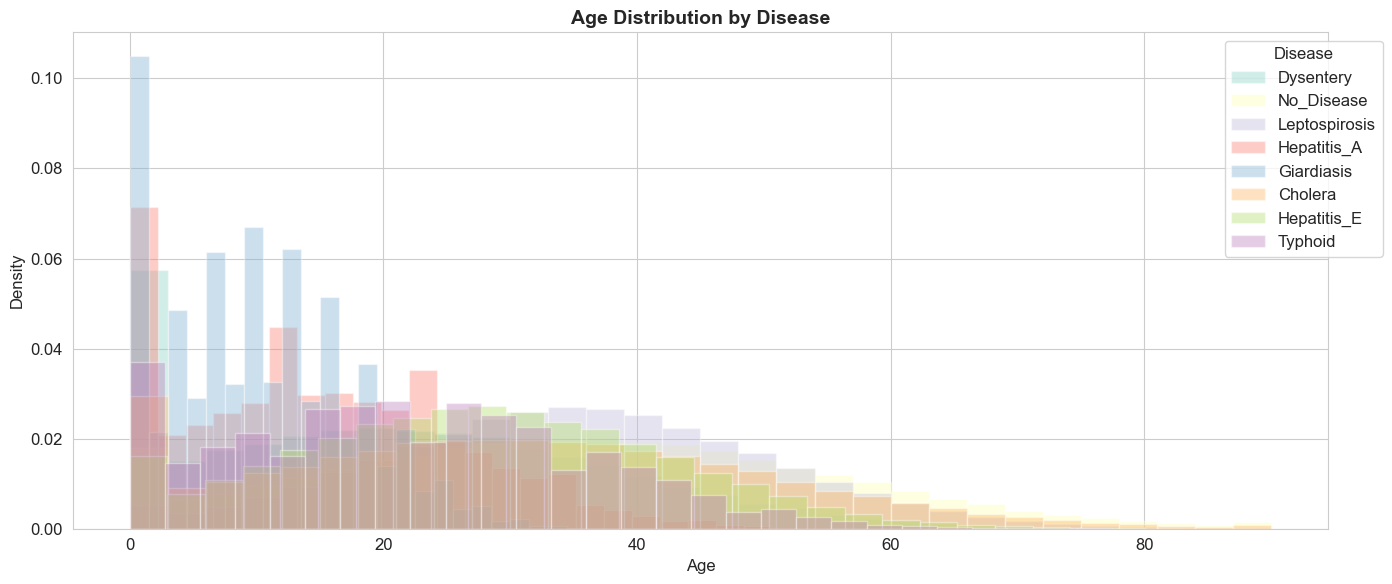

In [25]:
# Age distribution by disease
fig, ax = plt.subplots(figsize=(14, 6))
disease_list = data['disease'].unique()
for disease in disease_list:
    subset = data[data['disease'] == disease]['age']
    ax.hist(subset, bins=30, alpha=0.4, label=disease, density=True)
ax.set_title('Age Distribution by Disease', fontsize=14, fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Density')
ax.legend(title='Disease', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig('plots/11_age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Insight
- **Children (0–10) are the most vulnerable age group** — density spikes sharply at age 0–5 for almost all diseases, particularly Giardiasis (blue) and Hepatitis_A (pink). Immature immune systems and lower hygiene awareness drive this pattern.
- **Giardiasis disproportionately affects children under 10** — highest density peak of any disease in the 0–5 range, consistent with its known prevalence in children globally.
- **Hepatitis_A also spikes in early childhood (0–5)** — fecal-oral transmission is highest among toddlers in low-sanitation environments.
- **All diseases decline steadily after age 20** — adult immune systems and better hygiene habits reduce susceptibility.
- **No_Disease (yellow) is relatively flat across all ages** — healthy individuals are distributed evenly, no strong age protection effect.
- **Cholera, Typhoid, Leptospirosis show flatter age distributions** — these are environmentally driven (water contamination, flooding) rather than age-dependent, affecting all age groups more equally.
- **Above age 60 all diseases are near zero** — elderly population is underrepresented in the dataset, not necessarily less vulnerable in reality.
- **Implication for modeling**: `age` is a useful feature, especially for distinguishing Giardiasis and Hepatitis_A from other diseases. Keep as continuous — no binning needed.
- **Implication for LangChain advisory**: If predicted disease is Giardiasis or Hepatitis_A and age input is under 10, advisory should flag **"high-risk pediatric case — seek medical attention urgently"**.

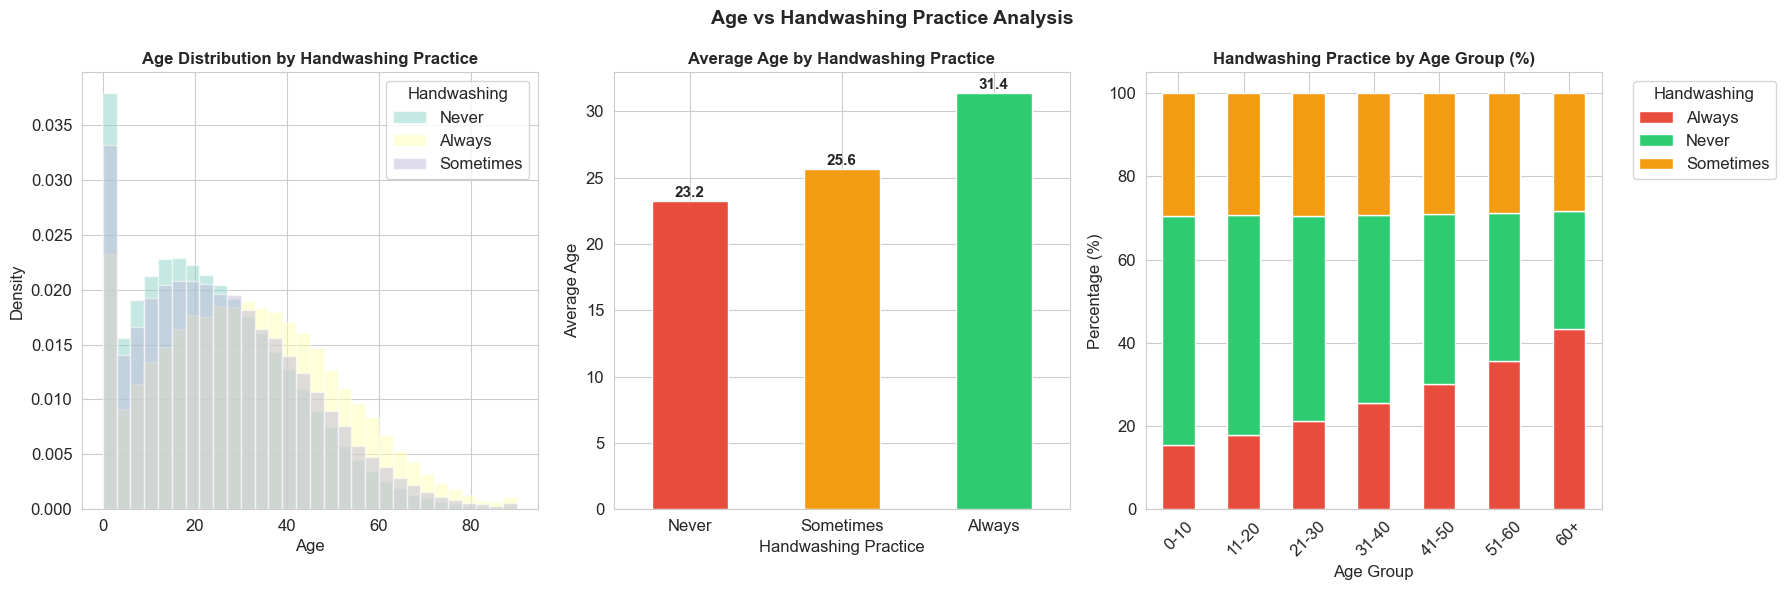

=== AVERAGE AGE BY HANDWASHING PRACTICE ===
                         count  mean   std  min   25%   50%   75%   max
handwashing_practice                                                   
Always                91582.00 31.36 19.26 0.00 17.00 30.00 45.00 90.00
Never                195012.00 23.22 16.70 0.00 10.00 21.00 34.00 90.00
Sometimes            118480.00 25.61 17.87 0.00 12.00 24.00 38.00 90.00

=== HANDWASHING PRACTICE BY AGE GROUP (%) ===
handwashing_practice  Always  Never  Sometimes
age_group                                     
0-10                   15.48  55.01      29.50
11-20                  17.78  52.83      29.39
21-30                  21.13  49.44      29.43
31-40                  25.41  45.37      29.22
41-50                  30.05  41.00      28.95
51-60                  35.70  35.59      28.71
60+                    43.24  28.38      28.39


In [26]:
# Age vs Handwashing Practice analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1 — Age distribution by handwashing practice
for practice in data['handwashing_practice'].unique():
    subset = data[data['handwashing_practice'] == practice]['age']
    axes[0].hist(subset, bins=30, alpha=0.5, label=practice, density=True)
axes[0].set_title('Age Distribution by Handwashing Practice', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Density')
axes[0].legend(title='Handwashing')

# Plot 2 — Average age per handwashing practice
avg_age = data.groupby('handwashing_practice')['age'].mean().reindex(['Never', 'Sometimes', 'Always'])
avg_age.plot(kind='bar', ax=axes[1], color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='white')
axes[1].set_title('Average Age by Handwashing Practice', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Handwashing Practice')
axes[1].set_ylabel('Average Age')
axes[1].tick_params(axis='x', rotation=0)
for i, val in enumerate(avg_age):
    axes[1].text(i, val + 0.3, f'{val:.1f}', ha='center', fontsize=11, fontweight='bold')

# Plot 3 — Age bins vs handwashing practice
data['age_group'] = pd.cut(data['age'], 
                            bins=[0, 10, 20, 30, 40, 50, 60, 100],
                            labels=['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '60+'])

age_hw = data.groupby(['age_group', 'handwashing_practice']).size().unstack(fill_value=0)
age_hw_pct = age_hw.div(age_hw.sum(axis=1), axis=0) * 100
age_hw_pct.plot(kind='bar', stacked=True, ax=axes[2], 
                color=['#e74c3c', '#2ecc71', '#f39c12'], edgecolor='white')
axes[2].set_title('Handwashing Practice by Age Group (%)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Age Group')
axes[2].set_ylabel('Percentage (%)')
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend(title='Handwashing', bbox_to_anchor=(1.05, 1))

plt.suptitle('Age vs Handwashing Practice Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/age_handwashing.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary stats
print('=== AVERAGE AGE BY HANDWASHING PRACTICE ===')
print(data.groupby('handwashing_practice')['age'].describe().round(2))

print('\n=== HANDWASHING PRACTICE BY AGE GROUP (%) ===')
print(age_hw_pct.round(2))

### Insight
- **Younger people (0–10) are the worst handwashers** — 55% of children never wash hands, only 15.5% always do. Children are both the most disease-vulnerable AND the least hygienic age group — a dangerous combination.
- **Handwashing improves consistently with age** — "Always" practice grows from 15.5% (0–10) to 43.2% (60+), showing a clear age-hygiene relationship. Older people have better hygiene habits.
- **"Never" handwashing drops steadily with age** — from 55% in children to 28.4% in 60+. Adults progressively adopt better habits as they age.
- **Average age confirms the pattern** — Never washers average age 23.2, Sometimes 25.6, Always 31.4. Older = cleaner habits.
- **"Sometimes" practice stays flat at ~29% across ALL age groups** — this group is age-independent, suggesting habitual inconsistency rather than age-driven behavior.
- **The 51–60 age group is the tipping point** — for the first time "Always" (35.7%) nearly matches "Never" (35.6%), meaning by late middle age hygiene habits become roughly balanced.